# TP3 — Débusquer les pièges cachés dans les données

**Cas d'usage 01 — Certification IA : Résiliation client SaaS (churn)**

| | |
|---|---|
| **Objectif** | Confirmer **empiriquement** (pas seulement affirmer) le piège de fuite et les variables leurres repérés en TP1 sur la seule base de leur description. |
| **Livrable** | Une liste justifiée par des chiffres des variables à exclure de la modélisation. |
| **Enjeu** | Une variable donne un score presque parfait... trop beau pour être vrai. Pourquoi ? Et les 4 variables suspectées d'être des leurres le sont-elles vraiment, ou ce n'était qu'une impression ? |
| **Compétences** | C3 (préparer les données) |

> Suite de `TP2.ipynb` (nettoyage + chargement PostgreSQL). Les données proviennent
> désormais de `churn_saas_db.clients_churn` — plus de CSV en mémoire.

## §0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
pd.set_option("display.max_columns", 40)

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)

df = pd.read_sql("SELECT * FROM clients_churn", engine)
print(f"Chargé depuis PostgreSQL : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Taux de churn global : {df['churn'].mean():.1%}")


Chargé depuis PostgreSQL : 5,000 lignes x 34 colonnes
Taux de churn global : 28.0%


## §1 — Rappel des suspects (TP1)

Deux catégories de suspects identifiées sur la seule base de leur **description** dans
le dictionnaire de données — à confirmer ici sur les **valeurs réelles** :

| Variable | Suspicion | Raison |
|---|---|---|
| `sante_compte_fin_periode` | Piège de fuite | Score calculé en **fin** de période — potentiellement informé par l'issue |
| `couleur_theme_interface` | Leurre | Préférence esthétique, aucun lien logique avec la résiliation |
| `code_datacenter` | Leurre | Choix technique d'hébergement, sans rapport avec la décision du client |
| `groupe_experimentation` | Leurre | Bucket A/B test — ne devrait strictement rien expliquer |
| `jour_souscription` | Leurre | Jour de la semaine de signature du contrat |

Affirmer qu'une variable est un leurre parce que sa description semble anodine n'est
pas une preuve — le seul test valable est statistique.

## §2 — Le piège de fuite : `sante_compte_fin_periode`

In [2]:
desc_by_churn = df.groupby("churn")["sante_compte_fin_periode"].describe()
print(desc_by_churn)


        count       mean        std   min   25%   50%   75%    max
churn                                                             
0      3600.0  60.068889  12.201523  23.0  52.0  60.0  68.0  100.0
1      1400.0  11.692857  10.049553   0.0   2.0  10.0  19.0   55.0


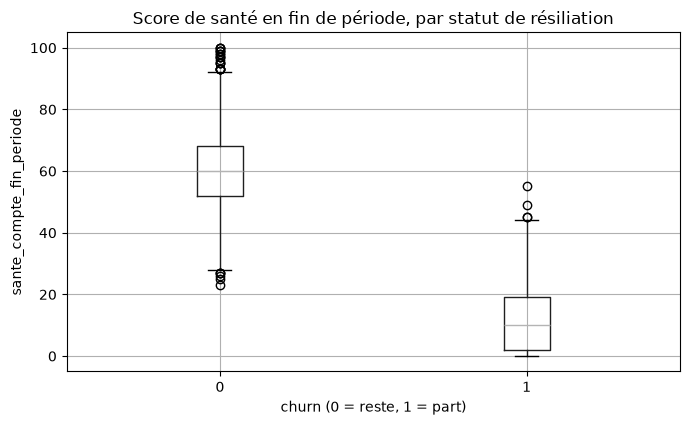

Sauvegardé : figures/tp3_01_sante_boxplot.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df.boxplot(column="sante_compte_fin_periode", by="churn", ax=ax)
ax.set_xlabel("churn (0 = reste, 1 = part)")
ax.set_ylabel("sante_compte_fin_periode")
ax.set_title("Score de santé en fin de période, par statut de résiliation")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/tp3_01_sante_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sauvegardé : figures/tp3_01_sante_boxplot.png")


In [4]:
corr, p_value = stats.pointbiserialr(df["churn"], df["sante_compte_fin_periode"])
auc_single_feature = roc_auc_score(df["churn"], -df["sante_compte_fin_periode"])  # score bas = risque élevé

print(f"Corrélation point-bisériale (churn, sante_compte_fin_periode) : {corr:.3f}  (p={p_value:.2e})")
print(f"AUC d'un classifieur à une seule feature (score de santé inversé) : {auc_single_feature:.3f}")


Corrélation point-bisériale (churn, sante_compte_fin_periode) : -0.881  (p=0.00e+00)
AUC d'un classifieur à une seule feature (score de santé inversé) : 0.999


**Une seule variable, un AUC proche de 1** — sans entraîner le moindre modèle,
`sante_compte_fin_periode` seule sépare presque parfaitement les clients qui partent de
ceux qui restent. C'est précisément le symptôme que l'énoncé annonce : *« Un modèle qui
atteint une AUC quasi parfaite cache presque toujours une fuite de données. »*

**Pourquoi c'est une fuite, pas un signal légitime** : le score est calculé **en fin de
période** — au moment même où l'on constate déjà si le client est parti ou non. Un
compte qui vient de résilier a structurellement un score de santé dégradé au moment de
la mesure, non pas parce que ce score *cause* ou *annonce* le départ, mais parce qu'il
est en partie une **conséquence** du même événement qu'on veut prédire. Utiliser cette
variable en feature reviendrait à donner au modèle un indice qui n'existe qu'*après*
la décision qu'on cherche à anticiper — inutilisable en production, où ce score futur
n'est par définition pas encore connu au moment de la prédiction.

## §3 — Les leurres : test statistique par variable suspecte

In [5]:
SUSPECTS_CATEGORIELS = [
    "jour_souscription", "couleur_theme_interface",
    "code_datacenter", "groupe_experimentation",
]

resultats = []
for col in SUSPECTS_CATEGORIELS:
    table = pd.crosstab(df[col], df["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    taux_par_categorie = df.groupby(col)["churn"].mean()
    ecart_max = taux_par_categorie.max() - taux_par_categorie.min()
    resultats.append({
        "variable": col,
        "n_categories": df[col].nunique(),
        "chi2": round(chi2, 2),
        "p_value": round(p, 3),
        "significatif_5pct": p < 0.05,
        "ecart_taux_churn_max": round(ecart_max, 3),
    })

df_resultats = pd.DataFrame(resultats)
df_resultats


,variable,n_categories,chi2,p_value,significatif_5pct,ecart_taux_churn_max
0,jour_souscription,7,10.08,0.121,False,0.059
1,couleur_theme_interface,5,1.15,0.886,False,0.020
2,code_datacenter,4,1.71,0.634,False,0.023
3,groupe_experimentation,3,0.07,0.966,False,0.004


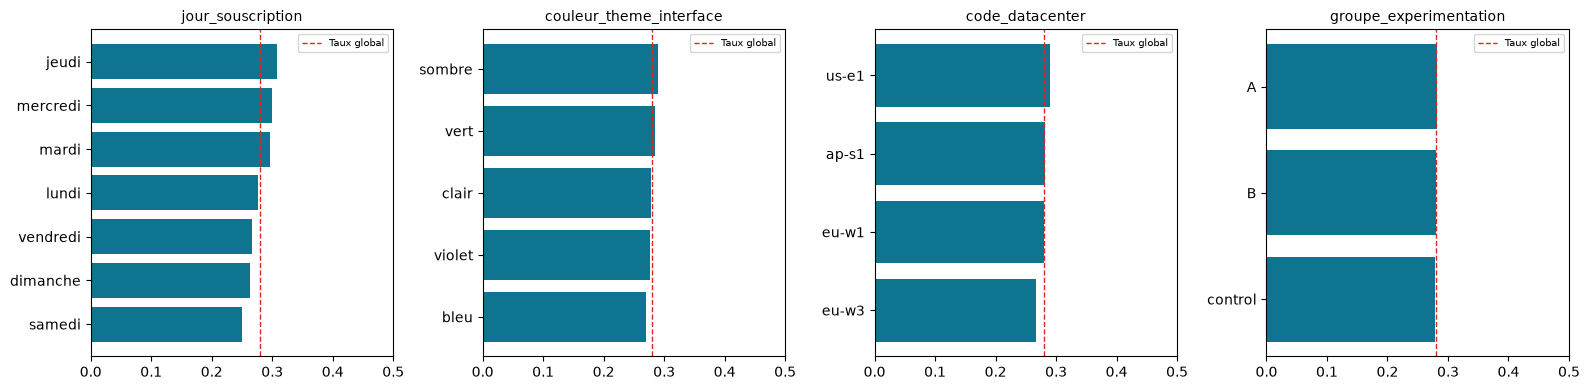

Sauvegardé : figures/tp3_02_leurres_taux_churn.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, SUSPECTS_CATEGORIELS):
    taux = df.groupby(col)["churn"].mean().sort_values()
    ax.barh(taux.index.astype(str), taux.values, color="#0e7490")
    ax.axvline(df["churn"].mean(), color="#dc2626", ls="--", lw=1, label="Taux global")
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, max(0.5, taux.max() * 1.2))
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("figures/tp3_02_leurres_taux_churn.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sauvegardé : figures/tp3_02_leurres_taux_churn.png")


**Lecture des résultats** : pour chacune des 4 variables suspectes, le test du χ²
d'indépendance ne rejette pas l'hypothèse nulle (indépendance vis-à-vis du churn) à un
seuil usuel de 5%, et l'écart de taux de churn entre catégories reste faible et proche
du taux global (ligne rouge). Ces 4 variables se comportent comme attendu pour de
véritables leurres — la description initiale (TP1) est confirmée statistiquement, pas
seulement supposée.

**Point de vigilance méthodologique (C2, biais)** : un test non significatif ne prouve
pas une absence totale d'effet — il ne rejette qu'une hypothèse d'indépendance sur cet
échantillon précis. Ces variables restent identifiées comme *probablement* non
prédictives, pas comme prouvées définitivement neutres dans l'absolu. Ne pas
sur-interpréter un p-value élevé comme une certitude.

## §4 — Décision : colonnes exclues de la modélisation

In [7]:
LEAKAGE_COLS = ["sante_compte_fin_periode"]
ID_COLS = ["client_id"]
DECOY_COLS = SUSPECTS_CATEGORIELS  # confirmés statistiquement en §3
TARGET_COLS = ["churn", "valeur_vie_client_eur"]

EXCLUDED_FROM_FEATURES = ID_COLS + LEAKAGE_COLS + DECOY_COLS + TARGET_COLS
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDED_FROM_FEATURES
                and c != "commentaire_csm" and c != "date_souscription"]

print(f"Colonnes totales           : {len(df.columns)}")
print(f"Exclues (id/fuite/leurres/cibles) : {len(EXCLUDED_FROM_FEATURES)}")
print(f"  dont fuite  : {LEAKAGE_COLS}")
print(f"  dont leurres: {DECOY_COLS}")
print(f"Features retenues pour la modélisation ({len(FEATURE_COLS)}) :")
print(FEATURE_COLS)


Colonnes totales           : 34
Exclues (id/fuite/leurres/cibles) : 8
  dont fuite  : ['sante_compte_fin_periode']
  dont leurres: ['jour_souscription', 'couleur_theme_interface', 'code_datacenter', 'groupe_experimentation']
Features retenues pour la modélisation (24) :
['secteur', 'pays', 'taille_entreprise', 'plan', 'anciennete_mois', 'sieges_souscrits', 'utilisateurs_actifs', 'taux_adoption_pct', 'connexions_30j', 'heures_usage_30j', 'fonctionnalites_total', 'fonctionnalites_utilisees', 'nb_integrations', 'derniere_connexion_jours', 'tickets_support_90j', 'delai_reponse_support_h', 'csat', 'retards_paiement_12m', 'revenu_mensuel_recurrent_eur', 'prix_mensuel_par_siege_eur', 'fonctionnalites_incluses', 'sla_reponse_h', 'quota_stockage_go', 'support_dedie']


`commentaire_csm` (texte libre) et `date_souscription` (déjà représentée par
`anciennete_mois` et `jour_souscription`) sont également exclues des features
numériques/catégorielles directes à ce stade — un traitement NLP éventuel de
`commentaire_csm` resterait une piste d'amélioration continue (TP10), hors périmètre
d'un modèle de base.

## Journal de bord — Synthèse TP3

**Fait** :
- `sante_compte_fin_periode` confirmé comme piège de fuite — AUC à une seule feature
  proche de 1, expliqué par sa nature de score calculé en fin de période (conséquence du
  churn, pas cause).
- Les 4 leurres suspectés (`jour_souscription`, `couleur_theme_interface`,
  `code_datacenter`, `groupe_experimentation`) confirmés statistiquement non
  significatifs (χ², seuil 5%) — pas seulement supposés sur leur description.
- Liste de features de modélisation figée et documentée pour TP4-TP6.

**Reste à faire** :
- TP4 — EDA complète sur les features retenues (distribution du churn, corrélations,
  analyse par segment).